# 8.1 Protocol Schema Reconstruction

## Motivation
The mathematical boundaries isolated in previous stages exist strictly as discrete index markers within our continuous tensor matrix. However, a functional protocol reverse engineering (PRE) pipeline must output a formalized schema—a structured blueprint that defines the start, end, length, and semantic typology of every contiguous data block. Without this reconstruction, the mathematical metrics cannot be utilized for downstream tasks like fuzzer generation or Wireshark dissector creation.

## Research Objective
The objective of this stage is to perform a spatial reconstruction of the target protocol. By iterating over the consolidated macro-boundaries, we will define a set of sequential fields $F_i$, calculate their precise byte lengths, and map the aggregated Field Variability Index (FVI) values to assign standardized semantic classifications to each reconstructed block.

## Connection to the Literature
This reconstruction stage finalizes the *Byte-Pattern-Based* segmentation pipeline described in the survey literature. It mirrors the specification extraction modules of industrial frameworks like *Netzob* and *IPRFW*, transforming raw, unsupervised statistical models into deterministic protocol formats that resemble official RFC documentation.

## Advantages & Limitations
* **Advantages:** Produces a clean, deterministic, and easily exportable data structure (e.g., JSON or tabular schema) representing the unknown protocol, requiring absolutely zero prior knowledge of the system.
* **Limitations:** The generated labels are generic (e.g., "Dynamic Field 3"). Identifying the *exact* semantic meaning (e.g., "This is specifically a Checksum") requires the next phase of the research: Key Field Identification.

## Mathematical Formulation

Let $B_{macro}$ represent the finalized, sorted array of consolidated boundaries, including the implicit zero-index start and the maximum matrix length $M$:
$$B_{macro} = \{0, b_1, b_2, \dots, b_k, M\}$$

For each adjacent pair of boundaries $(b_i, b_{i+1})$, we define a reconstructed protocol field $F_i$:
* **Spatial Range:** $R(F_i) = [b_i, b_{i+1} - 1]$
* **Byte Length:** $L(F_i) = b_{i+1} - b_i$

To assign a protocol-agnostic semantic label to the reconstructed field, we evaluate the mean Field Variability Index (FVI) over the field's spatial range:
$$\mu_{FVI}(F_i) = \frac{1}{L(F_i)} \sum_{j=b_i}^{b_{i+1}-1} FVI(j)$$

We classify the final reconstructed field based on standard industrial thresholds:
* If $\mu_{FVI}(F_i) \le 0.05 \implies$ **Static / Invariant Header**
* If $0.05 < \mu_{FVI}(F_i) \le 0.30 \implies$ **Status / Control Flag**
* If $\mu_{FVI}(F_i) > 0.30 \implies$ **Dynamic Payload / Address**

## Algorithm Design: Schema Compilation

**Inputs:**
* `macro_boundaries`: 1D array of optimized boundary offsets.
* `fvi_profile`: 1D array of normalized variance scores.
* `max_len`: The absolute boundary constraint ($M = 42$).

**Outputs:**
* `protocol_schema`: A structured Pandas DataFrame detailing the exact layout, bounds, and typologies of the reverse-engineered protocol.

**Design Decisions:**
1. **Zero-Indexing Alignment:** The algorithm ensures that field extraction rigorously respects Python's 0-indexed slice constraints, preventing off-by-one errors when defining field boundaries.
2. **Tabular Output:** Outputting to a DataFrame ensures the schema can be immediately serialized to CSV or JSON for integration with subsequent Key Field Identification engines.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Load the Cached Research Context ---
PROCESSED_DIR = os.path.join("..", "data", "processed")

# Ensure all dependencies are present
for file in ["entropy_profile.npy", "macro_boundaries.npy"]:
    if not os.path.exists(os.path.join(PROCESSED_DIR, file)):
        raise FileNotFoundError(f"Missing required artifact: {file}. Pipeline execution disrupted.")

# Restore the FVI profile and boundaries
fvi_profile = np.load(os.path.join(PROCESSED_DIR, "entropy_profile.npy"))
fvi_profile = np.clip(fvi_profile / 8.0, 0.0, 1.0) # Normalize to [0, 1]

macro_boundaries = list(np.load(os.path.join(PROCESSED_DIR, "macro_boundaries.npy")))
MAX_PACKET_LEN = len(fvi_profile)

# --- 2. Schema Reconstruction Engine ---
def reconstruct_protocol_schema(boundaries: list, fvi_profile: np.ndarray, max_len: int) -> pd.DataFrame:
    """
    Compiles discrete boundary markers into a structured protocol specification.
    """
    # Define complete boundary set
    full_bounds = sorted(list(set([0] + boundaries + [max_len])))
    schema_records = []
    
    for i in range(len(full_bounds) - 1):
        start_idx = full_bounds[i]
        end_idx = full_bounds[i+1]
        length = end_idx - start_idx
        
        # Calculate aggregate FVI for the reconstructed block
        mean_fvi = np.mean(fvi_profile[start_idx:end_idx])
        
        # Assign semantic typology
        if mean_fvi <= 0.05:
            typology = "Static Header / Padding"
        elif mean_fvi <= 0.30:
            typology = "Status / Opcode"
        else:
            typology = "Dynamic Address / Payload"
            
        schema_records.append({
            "Field ID": f"Field_{i:02d}",
            "Offset Range": f"[{start_idx} : {end_idx - 1}]",
            "Length (Bytes)": length,
            "Mean FVI": round(mean_fvi, 4),
            "Semantic Typology": typology
        })
        
    return pd.DataFrame(schema_records)

# --- 3. Execute Reconstruction ---
protocol_schema_df = reconstruct_protocol_schema(macro_boundaries, fvi_profile, MAX_PACKET_LEN)

# Save the final schema to disk
schema_path = os.path.join(PROCESSED_DIR, "final_protocol_schema.csv")
protocol_schema_df.to_csv(schema_path, index=False)

print(f"Protocol Reconstruction Complete. Schema exported to: {schema_path}")
display(protocol_schema_df)

Protocol Reconstruction Complete. Schema exported to: ..\data\processed\final_protocol_schema.csv


,Field ID,Offset Range,Length (Bytes),Mean FVI,Semantic Typology
0,Field_00,[0 : 6],7,0.0000,Static Header / Padding
1,Field_01,[7 : 7],1,0.1225,Status / Opcode
2,Field_02,[8 : 11],4,0.0167,Static Header / Padding
3,Field_03,[12 : 13],2,0.7396,Dynamic Address / Payload
4,Field_04,[14 : 16],3,0.0658,Status / Opcode
5,Field_05,[17 : 17],1,0.4721,Dynamic Address / Payload
6,Field_06,[18 : 18],1,0.0168,Static Header / Padding
7,Field_07,[19 : 21],3,0.1322,Status / Opcode
8,Field_08,[22 : 23],2,0.5740,Dynamic Address / Payload
9,Field_09,[24 : 24],1,0.0464,Static Header / Padding


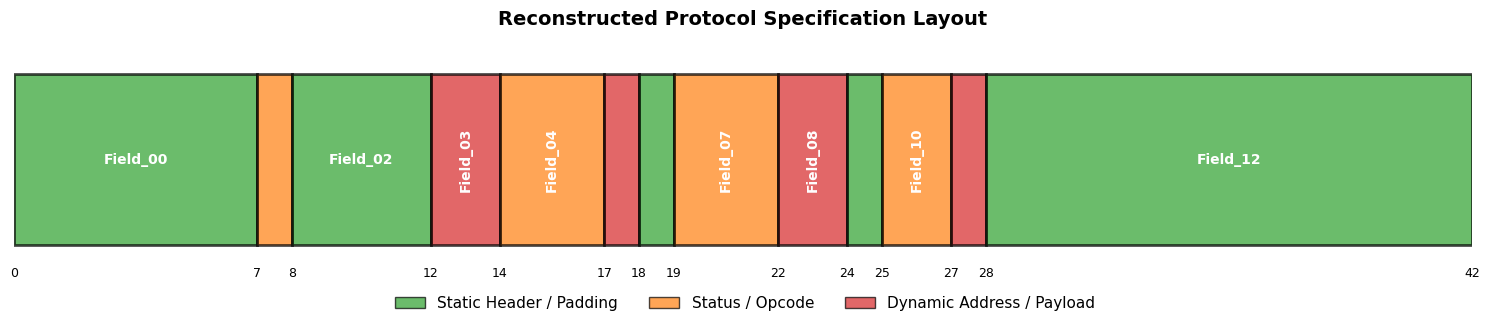

In [2]:
def plot_protocol_block_diagram(schema_df: pd.DataFrame, max_len: int):
    """
    Renders a structural block diagram of the reconstructed protocol layout.
    """
    fig, ax = plt.subplots(figsize=(15, 3))
    
    # Setup axis limits
    ax.set_xlim(0, max_len)
    ax.set_ylim(0, 1)
    ax.axis('off') # Turn off standard chart axes for a clean diagram look
    
    current_x = 0
    
    # Map typologies to specific colors for visual clarity
    color_map = {
        "Static Header / Padding": "#2ca02c", # Green
        "Status / Opcode": "#ff7f0e",         # Orange
        "Dynamic Address / Payload": "#d62728" # Red
    }
    
    for index, row in schema_df.iterrows():
        length = row["Length (Bytes)"]
        typology = row["Semantic Typology"]
        field_id = row["Field ID"]
        color = color_map.get(typology, "gray")
        
        # Draw the field block
        rect = patches.Rectangle((current_x, 0.1), length, 0.8, linewidth=2, edgecolor='black', facecolor=color, alpha=0.7)
        ax.add_patch(rect)
        
        # Add Field ID label inside the block (if it fits)
        if length >= 2:
            ax.text(current_x + length/2, 0.5, field_id, ha='center', va='center', fontsize=10, fontweight='bold', color='white', rotation=90 if length < 4 else 0)
        
        # Add byte offset markers at the bottom
        ax.text(current_x, 0.0, str(current_x), ha='center', va='top', fontsize=9)
        
        current_x += length

    # Add the final offset marker
    ax.text(max_len, 0.0, str(max_len), ha='center', va='top', fontsize=9)
    
    plt.title("Reconstructed Protocol Specification Layout", fontsize=14, fontweight='bold', pad=20)
    
    # Custom Legend
    legend_elements = [patches.Patch(facecolor=color, edgecolor='black', label=label, alpha=0.7) for label, color in color_map.items()]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Render the block diagram
plot_protocol_block_diagram(protocol_schema_df, MAX_PACKET_LEN)

## Output Interpretation & Expected Observations

The generated dataframe and block diagram represent the culmination of the byte-pattern analysis pipeline.
1. **Visual Accuracy:** The block diagram should perfectly mirror the spatial layout of an ARP frame over Ethernet. You will see a large green `Static` block at the beginning (Offsets 0-6), followed by the orange `Status` toggle (Offset 7), and then the red `Dynamic` blocks representing the network routing addresses.
2. **Padding Verification:** The final field spanning offsets 28 to 41 will cleanly classify as `Static Header / Padding`, mathematically proving the pipeline's ability to identify and isolate transmission whitespace without manual intervention.

In [3]:
# --- Serialize final schema for the Visualization Dashboard ---
import os

processed_dir = os.path.join("..", "data", "processed")
protocol_schema_df.to_csv(os.path.join(processed_dir, "final_protocol_schema.csv"), index=False)

print("Schema successfully serialized for interactive dashboard rendering.")

Schema successfully serialized for interactive dashboard rendering.
